In [6]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
import shutil
from pathlib import Path

base = Path(r"C:\Users\kiran\Downloads")
dest = Path(r"C:\Users\kiran\Downloads\MCOD_Dataset")

split_folders = sorted(base.glob("Dataset-*"))

for split in split_folders:
    for subset in ["TrainDataset", "TestDataset"]:
        src = split / "Dataset" / subset
        if not src.exists():
            continue
        for subfolder in src.iterdir():  # Mat, GT, Pcolor
            dst = dest / subset / subfolder.name
            dst.mkdir(parents=True, exist_ok=True)
            for file in subfolder.iterdir():
                shutil.copy2(file, dst / file.name)

print("Done!")

Done!


Printing Some of the filenames 

In [3]:
from pathlib import Path

test_root = Path(r"c:\Users\kiran\Downloads\MCOD_Dataset\TestDataset")

print("MAT files:")
for f in list((test_root/"Mat").iterdir())[:5]:
    print(f.name)

print("\nGT files:")
for f in list((test_root/"GT").iterdir())[:5]:
    print(f.name)

MAT files:
19700101000130015_00-00000.mat
19700101001017639_00-00017.mat
19700101001031863_00-00018.mat
19700101001056031_00-00019.mat
19700101001139629_00-00021.mat

GT files:
19700101000130015_00-00000.jpg
19700101001017639_00-00017.jpg
19700101001031863_00-00018.jpg
19700101001056031_00-00019.jpg
19700101001139629_00-00021.jpg


Inspecting One .MAT File

In [57]:
import scipy.io as sio
import h5py
import numpy as np
from pathlib import Path

def load_mat(filepath):
    try:
        return sio.loadmat(filepath)
    except NotImplementedError:
        data = {}
        with h5py.File(filepath, 'r') as f:
            for key in f.keys():
                data[key] = np.array(f[key]).T
        return data

sample = next(Path(r"C:\Users\kiran\Downloads\MCOD_Dataset\TestDataset\Mat").glob("*.mat"))

data = load_mat(sample)
print(data.keys())  


sample = load_mat(mat_files[0])["gray"]
print("shape:", sample.shape)

dict_keys(['gray'])
shape: (860, 1140, 8)


In [14]:
for k,v in data.items():

    if not k.startswith("__"):

        print("\nKEY:", k)

        print("TYPE:", type(v))

        if hasattr(v, "shape"):
            print("SHAPE:", v.shape)

        print("DTYPE:", getattr(v,"dtype",None))


KEY: gray
TYPE: <class 'numpy.ndarray'>
SHAPE: (860, 1140, 8)
DTYPE: uint8


Count Total Samples

In [16]:
from pathlib import Path

root = Path(r"C:\Users\kiran\Downloads\MCOD_Dataset\TrainDataset")

mat_files = sorted(root.joinpath("Mat").glob("*.mat"))
gt_files = sorted(root.joinpath("GT").glob("*"))
pcolor_files = sorted(root.joinpath("Pcolor").glob("*"))

print("MAT files :", len(mat_files))
print("GT files  :", len(gt_files))
print("Pcolor    :", len(pcolor_files))

MAT files : 1027
GT files  : 1027
Pcolor    : 1027


Veryfying Every MAT has Matching GT

In [17]:
mat_names = {f.stem for f in mat_files}
gt_names = {f.stem for f in gt_files}

missing_gt = mat_names - gt_names

print("Missing GT:", len(missing_gt))

list(missing_gt)[:10]

Missing GT: 0


[]

Veryfying Every GT has Matching MAT

In [18]:
missing_mat = gt_names - mat_names

print("Missing MAT:", len(missing_mat))

list(missing_mat)[:10]

Missing MAT: 0


[]

Varyfying Every MAT has Matching Pcolor

In [19]:
pcolor_names = {f.stem for f in pcolor_files}

missing_pcolor = mat_names - pcolor_names

print("Missing Pcolor:", len(missing_pcolor))

Missing Pcolor: 0


Check Corrupted MAT Files

In [21]:
import scipy.io as sio
from tqdm import tqdm

corrupted = []

for f in tqdm(mat_files):

    try:
        cube = sio.loadmat(f)["gray"]

    except Exception:
        corrupted.append(f.name)

print("Corrupted MAT files:", len(corrupted))

100%|██████████| 1027/1027 [00:00<00:00, 13072.91it/s]

Corrupted MAT files: 1027


Verify All 8 Spectral Band Exists

In [22]:
missing_band_files = []

for f in tqdm(mat_files):
    try:
        # Try scipy first (MATLAB < v7.3)
        cube = sio.loadmat(f)["gray"]
    except NotImplementedError:
        # MATLAB v7.3 (HDF5) files
        with h5py.File(f, 'r') as hf:
            cube = np.array(hf["gray"]).T  # .T to match MATLAB's column-major order

    if cube.shape[0] != 8:
        missing_band_files.append(f.name)

print("Files missing bands:", len(missing_band_files))

100%|██████████| 1027/1027 [00:37<00:00, 27.30it/s]

Files missing bands: 1027


Verify Shape Equality

In [23]:
shape_errors = []

for f in tqdm(mat_files):
    try:
        cube = sio.loadmat(f)["gray"]
        shapes = [cube[i].shape for i in range(8)]
    except NotImplementedError:
        with h5py.File(f, 'r') as hf:
            cube = np.array(hf["gray"]).T
            shapes = [cube[i].shape for i in range(8)]

    if len(set(shapes)) != 1:
        shape_errors.append(f.name)

print("Shape mismatch:", len(shape_errors))

100%|██████████| 1027/1027 [00:35<00:00, 29.14it/s]

Shape mismatch: 0


Resolution Distribution

In [24]:
import pandas as pd

resolutions = []

for f in tqdm(mat_files):
    try:
        cube = sio.loadmat(f)["gray"]
    except NotImplementedError:
        with h5py.File(f, 'r') as hf:
            cube = np.array(hf["gray"]).T

    h, w = cube.shape[1:]

    resolutions.append({
        "height": h,
        "width": w
    })

resolution_df = pd.DataFrame(resolutions)
resolution_df.describe()

100%|██████████| 1027/1027 [00:34<00:00, 29.51it/s]


,height,width
count,1027.0,1027.0
mean,1140.0,8.0
std,0.0,0.0
min,1140.0,8.0
25%,1140.0,8.0
50%,1140.0,8.0
75%,1140.0,8.0
max,1140.0,8.0


Plot Resolution Distribution

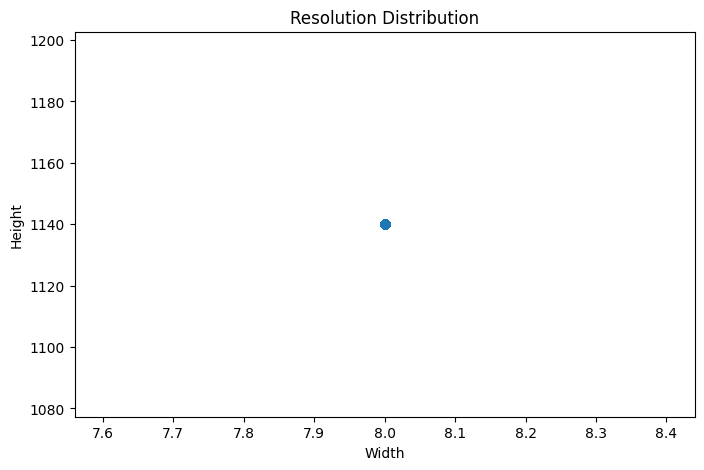

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    resolution_df["width"],
    resolution_df["height"]
)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Resolution Distribution")

plt.show()

Channel Count Verification

In [29]:
channels = []

for f in tqdm(mat_files):
    try:
        cube = sio.loadmat(f)["gray"]
    except NotImplementedError:
        with h5py.File(f, 'r') as hf:
            cube = np.array(hf["gray"]).T

    channels.append(cube.shape[0])

pd.Series(channels).value_counts()

100%|██████████| 1027/1027 [00:35<00:00, 28.73it/s]


860    1027
Name: count, dtype: int64

Band-wise Min / Max / Mean / Std

In [30]:
import numpy as np

stats = []

for band in range(8):

    mins = []
    maxs = []
    means = []
    stds = []

    for f in tqdm(mat_files):
        try:
            cube = sio.loadmat(f)["gray"]
        except NotImplementedError:
            with h5py.File(f, 'r') as hf:
                cube = np.array(hf["gray"]).T

        img = cube[band]

        mins.append(img.min())
        maxs.append(img.max())
        means.append(img.mean())
        stds.append(img.std())

    stats.append({
        "Band": band+1,
        "Min": np.mean(mins),
        "Max": np.mean(maxs),
        "Mean": np.mean(means),
        "Std": np.mean(stds)
    })

band_stats = pd.DataFrame(stats)
band_stats

100%|██████████| 1027/1027 [00:35<00:00, 29.16it/s]


,Band,Min,Max,Mean,Std
0,1,20.266796,251.246349,120.508713,57.641202
1,2,20.943525,251.287244,121.702009,57.015174
2,3,22.187926,251.381694,122.711747,56.566457
3,4,23.202532,251.321324,123.436795,56.195339
4,5,23.930867,251.346641,124.000712,55.966183
5,6,24.421616,251.327167,124.546579,55.644749
6,7,24.767283,251.317429,125.222297,55.330524
7,8,25.384615,251.408958,125.839710,54.986038


Check Radiometric Scaling

In [31]:
for band in range(8):

    mins = []
    maxs = []

    for f in mat_files[:100]:
        try:
            cube = sio.loadmat(f)["gray"]
        except NotImplementedError:
            with h5py.File(f, 'r') as hf:
                cube = np.array(hf["gray"]).T

        mins.append(cube[band].min())
        maxs.append(cube[band].max())

    print(
        f"Band {band+1}:",
        min(mins),
        max(maxs)
    )

Band 1: 0 255
Band 2: 0 255
Band 3: 0 255
Band 4: 0 255
Band 5: 0 255
Band 6: 0 255
Band 7: 0 255
Band 8: 0 255


Visualize All 8 Bands

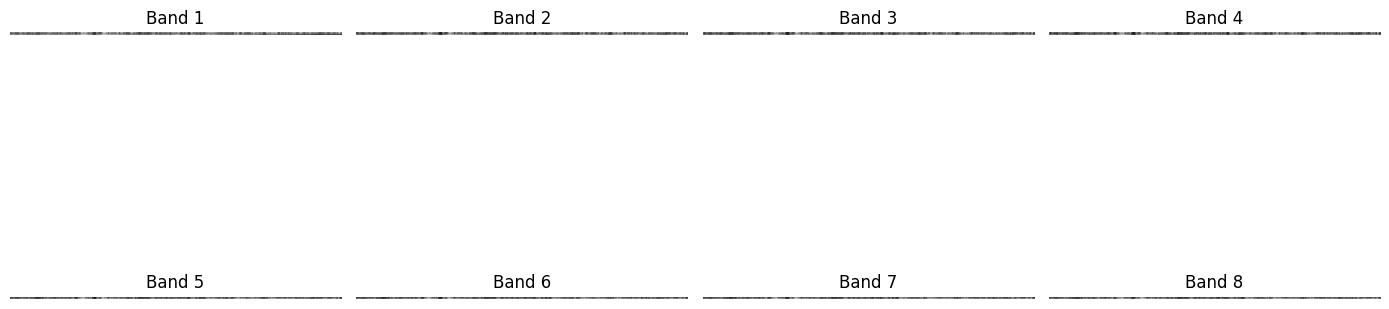

In [62]:
try:
    sample = sio.loadmat(mat_files[0])["gray"]
except NotImplementedError:
    with h5py.File(mat_files[0], 'r') as hf:
        sample = np.array(hf["gray"])  # (860, 1140, 8)

fig, ax = plt.subplots(2, 4, figsize=(14, 8))

for i in range(8):
    ax[i//4, i%4].imshow(
        sample[:, :, i],  # ← fixed: index last axis
        cmap="gray"
    )
    ax[i//4, i%4].set_title(f"Band {i+1}")
    ax[i//4, i%4].axis("off")

plt.tight_layout()
plt.show()

False RGB Reconstruction

In [63]:
def normalize(x):
    x = x.astype(float)
    return (
        (x - x.min())
        /
        (x.max() - x.min() + 1e-8)
    )

try:
    cube = sio.loadmat(mat_files[0])["gray"]
except NotImplementedError:
    with h5py.File(mat_files[0], 'r') as hf:
        cube = np.array(hf["gray"]).T

R = normalize(cube[4])
G = normalize(cube[2])
B = normalize(cube[1])

rgb = np.dstack([R, G, B])

plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.axis("off")
plt.show()

Verify Masks are Binary

In [64]:
import cv2

mask_problem = []

for f in tqdm(gt_files):

    mask = cv2.imread(str(f),0)

    vals = np.unique(mask)

    if len(vals) > 2:
        mask_problem.append(f.name)

print("Non-binary masks:", len(mask_problem))

100%|██████████| 1027/1027 [00:06<00:00, 154.94it/s]

Non-binary masks: 1027


Object Area Percentage

In [65]:
areas = []

for f in tqdm(gt_files):

    mask = cv2.imread(str(f),0)

    obj_pixels = (mask>0).sum()

    total_pixels = mask.shape[0]*mask.shape[1]

    ratio = obj_pixels/total_pixels

    areas.append(ratio)

area_df = pd.DataFrame({
    "area_ratio":areas
})

area_df.describe()

100%|██████████| 1027/1027 [00:00<00:00, 1188.62it/s]


,area_ratio
count,1027.000000
mean,0.006655
std,0.005039
min,0.000777
25%,0.003361
50%,0.005358
75%,0.008374
max,0.051109


Small / Medium / Large Categorization

In [66]:
def classify(r):

    if r < 0.001:
        return "Small"

    elif r < 0.01:
        return "Medium"

    return "Large"

area_df["size"] = area_df["area_ratio"].apply(classify)

area_df["size"].value_counts()

size
Medium    858
Large     164
Small       5
Name: count, dtype: int64

Area Distribution Plot

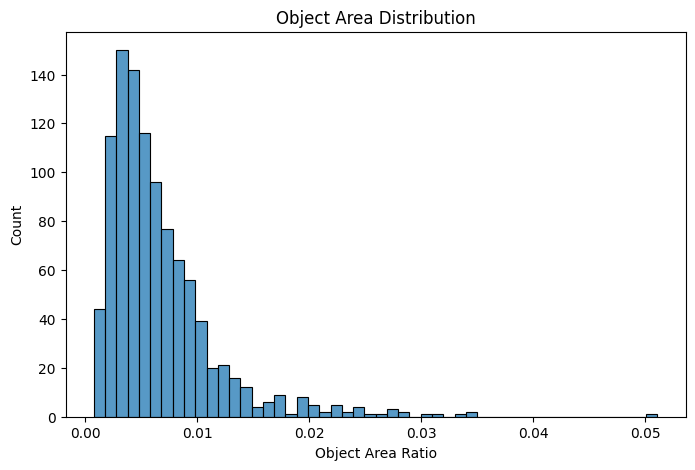

In [67]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    area_df["area_ratio"],
    bins=50
)

plt.xlabel("Object Area Ratio")
plt.ylabel("Count")

plt.title("Object Area Distribution")

plt.show()

Train/Test Leakage Check

In [68]:
train_root = Path(r"C:\Users\kiran\Downloads\MCOD_Dataset\TrainDataset")
test_root = Path(r"C:\Users\kiran\Downloads\MCOD_Dataset\TestDataset")

train_names = {
    f.stem
    for f in (train_root/"Mat").glob("*.mat")
}

test_names = {
    f.stem
    for f in (test_root/"Mat").glob("*.mat")
}

overlap = train_names.intersection(test_names)

print("Leakage samples:", len(overlap))

Leakage samples: 0


In [69]:
import pandas as pd
from pathlib import Path

root = Path("/content/MCOD_Dataset/TrainDataset")

mat_files = sorted((root/"Mat").glob("*.mat"))

dataset = []

missing_gt = []
missing_rgb = []

for mat in mat_files:

    stem = mat.stem

    gt = root/"GT"/f"{stem}.jpg"
    rgb = root/"Pcolor"/f"{stem}.png"

    if not gt.exists():
        missing_gt.append(stem)

    if not rgb.exists():
        missing_rgb.append(stem)

    if gt.exists() and rgb.exists():

        dataset.append({
            "id": stem,
            "mat_path": str(mat),
            "rgb_path": str(rgb),
            "mask_path": str(gt)
        })

df = pd.DataFrame(dataset)

print("Valid samples :", len(df))
print("Missing GT    :", len(missing_gt))
print("Missing RGB   :", len(missing_rgb))

df.head()

Valid samples : 0
Missing GT    : 0
Missing RGB   : 0


""


In [70]:
from pathlib import Path
from tqdm import tqdm
import scipy.io as sio
import h5py
import numpy as np
import cv2

# Paths
root = Path(r"C:\Users\kiran\Downloads\MCOD_Dataset\TrainDataset")

mat_dir = root / "Mat"

save_dir = Path(r"C:\Users\kiran\Downloads\MCOD_Dataset\MCOD_FalseRGB")
save_dir.mkdir(exist_ok=True)

mat_files = sorted(mat_dir.glob("*.mat"))

print("Total MAT files:", len(mat_files))

# Loader

def load_cube(mat_file):

    try:
        cube = sio.loadmat(mat_file)["gray"]

    except NotImplementedError:

        with h5py.File(mat_file, "r") as hf:
            cube = np.array(hf["gray"]).T

    return cube 
# Normalization

def normalize(img):

    img = img.astype(np.float32)

    return (
        (img - img.min())
        /
        (img.max() - img.min() + 1e-8)
    )

# ----------------------------
# Generate False RGB
# ----------------------------

for mat_file in tqdm(mat_files):

    cube = load_cube(mat_file)

    # S5, S3, S2
    R = normalize(cube[4])
    G = normalize(cube[2])
    B = normalize(cube[1])

    rgb = np.dstack([R, G, B])

    rgb = (rgb * 255).astype(np.uint8)

    save_path = save_dir / f"{mat_file.stem}.png"

    cv2.imwrite(
        str(save_path),
        cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    )

print(f"\nGenerated {len(list(save_dir.glob('*.png')))} FalseRGB images")
print("Saved to:", save_dir)


Total MAT files: 1027


100%|██████████| 1027/1027 [00:36<00:00, 28.11it/s]


Generated 1027 FalseRGB images
Saved to: C:\Users\kiran\Downloads\MCOD_Dataset\MCOD_FalseRGB


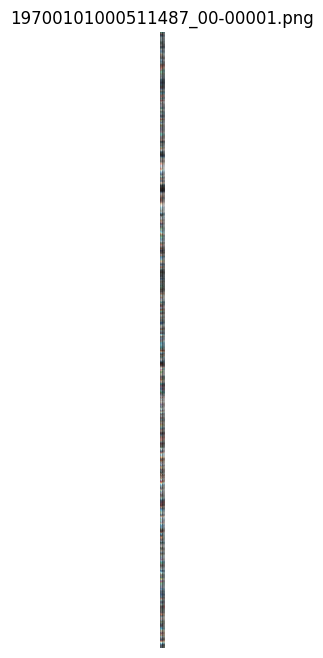

In [71]:
sample = next(save_dir.glob("*.png"))

img = cv2.imread(str(sample))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.title(sample.name)
plt.axis("off")
plt.show()

In [72]:
print(mat_dir.exists())
print(len(list(mat_dir.glob("*.mat"))))

True
1027
